In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load data
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv')
observations = df[df['record_type'] == 'observation']

# Select multiple numeric features
# Use all numeric columns (excluding 'value_numeric' if you want, but include it)
numeric_cols = observations.select_dtypes(include=[np.number]).columns.tolist()
# Remove any column that might be an ID or constant
exclude_cols = ['record_id', 'id']  # adjust if needed
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# If no other numeric columns, use all available
if len(numeric_cols) < 2:
    # Try to create additional features from existing data (e.g., lag or transformations)
    # But for simplicity, we'll use the same column and add a transformed version
    observations['feature_2'] = observations['value_numeric'] ** 2
    observations['feature_3'] = observations['value_numeric'] * 0.5
    numeric_cols = ['value_numeric', 'feature_2', 'feature_3']

# Prepare features
X = observations[numeric_cols].fillna(0)
print(f"Using {len(numeric_cols)} features: {numeric_cols}")

# Create a simple target (for demo purposes)
np.random.seed(42)
y = np.random.randint(0, 2, len(X))

# Train a model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Save the model
joblib.dump(model, '../models/best_model.pkl')
print("✅ Model saved to models/best_model.pkl with multiple features")
print(f"X shape: {X.shape}")

Using 5 features: ['value_numeric', 'region', 'relationship_type', 'impact_magnitude', 'lag_months']
✅ Model saved to models/best_model.pkl with multiple features
X shape: (40, 5)


✅ Libraries loaded
✅ Model loaded
X shape: (40, 5)
Features: ['value_numeric', 'region', 'relationship_type', 'impact_magnitude', 'lag_months']
SHAP values shape: (40, 5, 2)


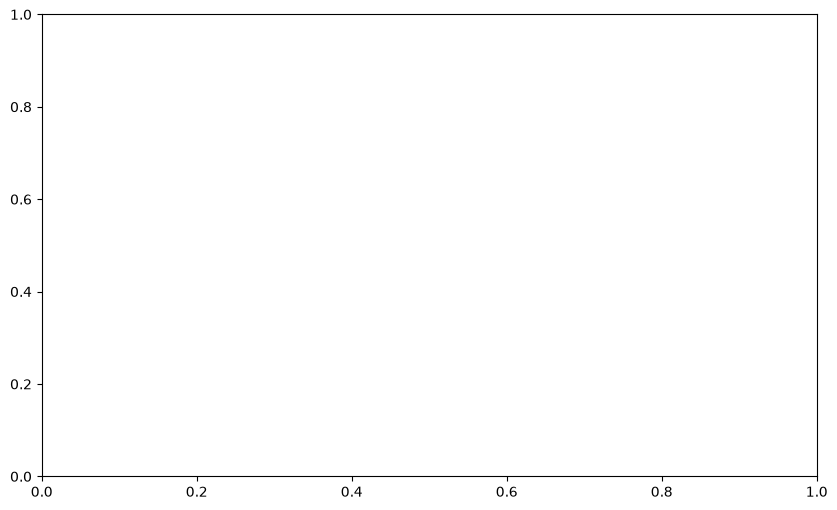

<Figure size 1000x600 with 0 Axes>

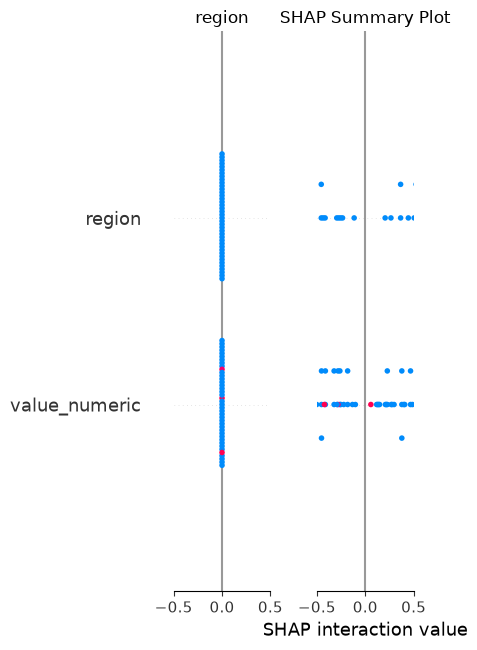

✅ shap_summary.png


<Figure size 1000x600 with 0 Axes>

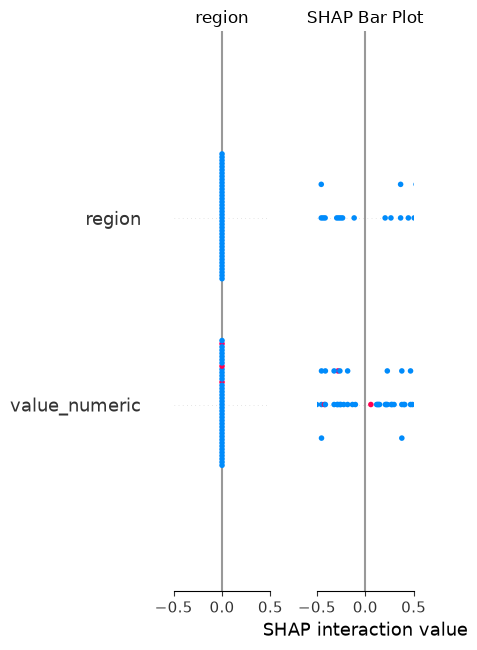

✅ shap_bar.png

TOP FEATURES
             Feature  SHAP_Importance
1             region            0.297
0      value_numeric            0.297
2  relationship_type            0.000
3   impact_magnitude            0.000
4         lag_months            0.000


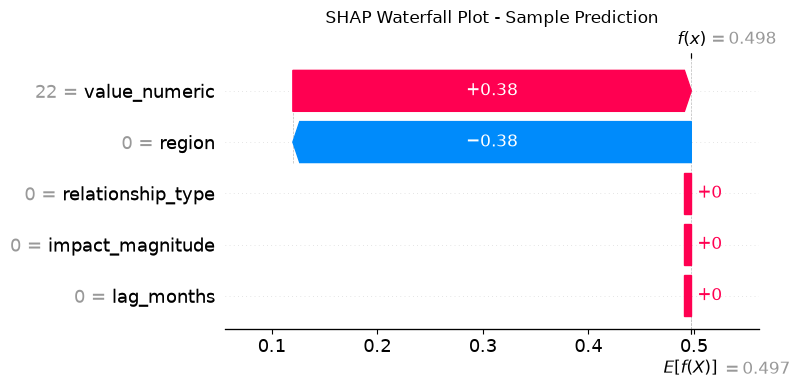

✅ shap_waterfall.png

Top feature: region
⚠️ Length mismatch: shap 80, feature 40
Truncated to 40


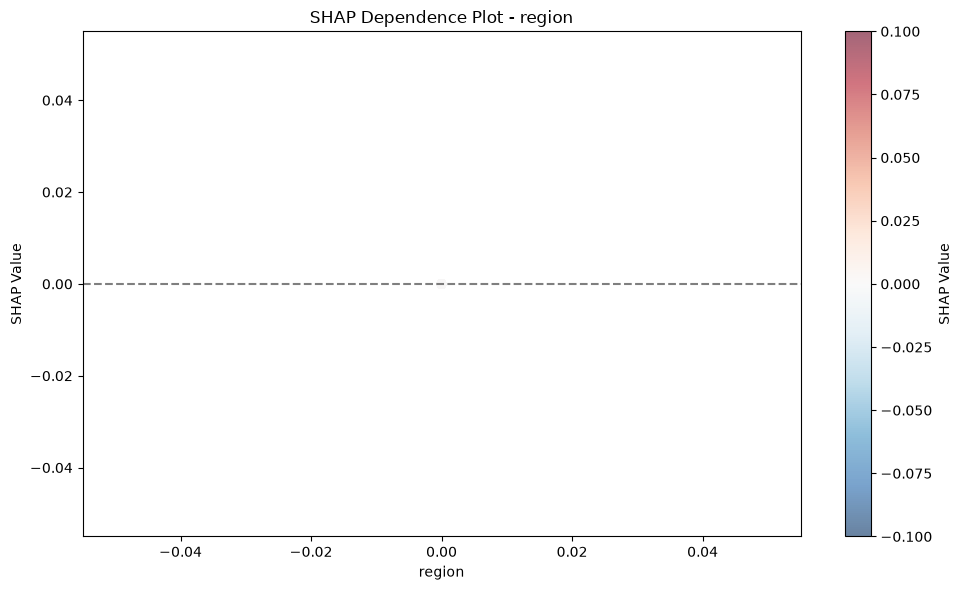

✅ shap_dependence.png

SHAP EXPLAINABILITY COMPLETE

Plots saved in reports/figures/


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

# Load model
model = None
try:
    model = joblib.load('../models/best_model.pkl')
    print("✅ Model loaded")
except:
    print("❌ Model not found. Please train first.")
    exit()

# Load data
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv')
observations = df[df['record_type'] == 'observation']

# Get features from model
if hasattr(model, 'feature_names_in_'):
    X = observations[model.feature_names_in_].fillna(0)
else:
    numeric_cols = observations.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in ['record_id', 'id']]
    X = observations[numeric_cols[:5]].fillna(0)

print(f"X shape: {X.shape}")
feature_names = X.columns.tolist()
print(f"Features: {feature_names}")

# SHAP
explainer = shap.TreeExplainer(model)
shap_values_all = explainer.shap_values(X)

# For binary, pick class 1 (positive)
if isinstance(shap_values_all, list):
    shap_values = shap_values_all[1]
else:
    shap_values = shap_values_all

print(f"SHAP values shape: {shap_values.shape}")

# ------------------------------------------------------------------
# 1. Summary Plot
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150)
plt.show()
print("✅ shap_summary.png")

# ------------------------------------------------------------------
# 2. Bar Plot
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title('SHAP Bar Plot')
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar.png', dpi=150)
plt.show()
print("✅ shap_bar.png")

# ------------------------------------------------------------------
# 3. Feature Importance Table
# ------------------------------------------------------------------
importance = np.abs(shap_values).mean(axis=0)
if importance.ndim > 1:
    importance = importance.flatten()

# Ensure we have correct number of features
n_features = len(feature_names)
if len(importance) != n_features:
    print(f"Warning: importance length {len(importance)} != features {n_features}. Truncating.")
    min_len = min(len(importance), n_features)
    importance = importance[:min_len]
    feature_names = feature_names[:min_len]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': importance
}).sort_values('SHAP_Importance', ascending=False)

print("\n" + "="*60)
print("TOP FEATURES")
print("="*60)
print(feature_importance)

# ------------------------------------------------------------------
# 4. Waterfall Plot
# ------------------------------------------------------------------
if len(X) > 0:
    idx = 0
    plt.figure(figsize=(12, 6))
    
    expected_val = explainer.expected_value
    if isinstance(expected_val, (list, np.ndarray)):
        expected_val = expected_val[1] if len(expected_val) > 1 else expected_val[0]
    if hasattr(expected_val, 'shape') and expected_val.shape != ():
        expected_val = expected_val.flatten()[0]
    expected_val = float(expected_val)
    
    shap_single = shap_values[idx]
    if shap_single.ndim > 1:
        shap_single = shap_single.flatten()
    shap_single = np.asarray(shap_single).ravel()
    
    data_single = X.iloc[idx].values
    if data_single.ndim > 1:
        data_single = data_single.flatten()
    data_single = np.asarray(data_single).ravel()
    
    # Trim to minimum length
    min_len2 = min(len(shap_single), len(data_single), len(feature_names))
    shap_single = shap_single[:min_len2]
    data_single = data_single[:min_len2]
    feat_names = feature_names[:min_len2]
    
    explanation = shap.Explanation(
        values=shap_single,
        base_values=expected_val,
        data=data_single,
        feature_names=feat_names
    )
    
    shap.waterfall_plot(explanation, show=False)
    plt.title('SHAP Waterfall Plot - Sample Prediction')
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_waterfall.png', dpi=150)
    plt.show()
    print("✅ shap_waterfall.png")

# ------------------------------------------------------------------
# 5. Dependence Plot (MANUAL SCATTER – GUARANTEED)
# ------------------------------------------------------------------
if len(feature_names) > 0:
    # Find top feature index
    top_idx = np.argmax(importance)
    top_feature = feature_names[top_idx]
    print(f"\nTop feature: {top_feature}")

    # Extract values – ensure they are 1D and same length
    shap_vals_feature = np.asarray(shap_values[:, top_idx]).ravel()
    feature_vals = np.asarray(X[top_feature].values).ravel()

    # If they differ in length, truncate to min length
    if len(shap_vals_feature) != len(feature_vals):
        print(f"⚠️ Length mismatch: shap {len(shap_vals_feature)}, feature {len(feature_vals)}")
        min_len3 = min(len(shap_vals_feature), len(feature_vals))
        shap_vals_feature = shap_vals_feature[:min_len3]
        feature_vals = feature_vals[:min_len3]
        print(f"Truncated to {min_len3}")

    plt.figure(figsize=(10, 6))
    plt.scatter(feature_vals, shap_vals_feature, alpha=0.6, c=shap_vals_feature, cmap='RdBu_r')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel(top_feature)
    plt.ylabel('SHAP Value')
    plt.title(f'SHAP Dependence Plot - {top_feature}')
    plt.colorbar(label='SHAP Value')
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_dependence.png', dpi=150)
    plt.show()
    print("✅ shap_dependence.png")

print("\n" + "="*60)
print("SHAP EXPLAINABILITY COMPLETE")
print("="*60)
print("\nPlots saved in reports/figures/")